# Parte 0 — Testes sintéticos

Antes de tocar no MOT17, um ambiente controlado onde **sabemos a resposta certa**. Quatro artefatos, três dos quais são reaproveitados nas partes seguintes:

1. **O gerador** (`src/dataset/sintetic.py::generate_video`) — vídeos 128×128 de 30–60 quadros, 5–15 elipses em movimento, tamanhos variados, ruído e contraste variáveis. Parâmetros expostos: número de objetos, velocidade típica e **duração da oclusão**. As elipses são desenhadas em ordem de profundidade, então uma passa atrás da outra e *realmente* desaparece.
2. **O simulador de detector** (`simulate_detector`) — recebe as caixas verdadeiras e as estraga: descarta $p\%$, adiciona ruído nas coordenadas, injeta falsos positivos. Serve para validar a Parte 1 inteira no sintético (e é o experimento da Parte 5).
3. **A métrica e seus testes** (`src/nn/metrics.py`, re-exportada em `metrics.py`) — IDF1, ID switches e fragmentações, com os três casos construídos à mão do enunciado.
4. **O baseline no piso fácil** — a associação ingênua da Parte 1 (`src/nn/tracking.py::Tracker` + `StaticMotion`) com poucas elipses, lentas e sem oclusão: IDF1 ≈ 1. Depois giramos os botões do gerador e mostramos onde ela começa a quebrar.

Convenção de dados em todo o repositório: uma **tabela** é um `np.ndarray (N, 7)` com colunas `frame, id, x1, y1, x2, y2, conf`, onde `conf` é a visibilidade no ground truth e a confiança nas detecções/previsões — é o `gt.txt` do MOT17 em xyxy.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.dataset.sintetic import generate_video, simulate_detector
from src.nn.boxes import FRAME, ID, X1, Y2, CONF, split_by_frame
from src.nn.metrics import (
    idf1, id_switches, identity_count_error, evaluate_tracking,
    mean_average_precision, detection_counts,
)
from src.nn.tracking import Tracker, StaticMotion, KalmanMotion
from src.plot.plot import (
    show_frames, plot_occlusion_trajectory, plot_detector_simulation,
    plot_breakdown, plot_tracks_timeline, id_color,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

## 1. O gerador

Cada objeto tem semi-eixos $(r_x, r_y)$ sorteados em `radius_range`, intensidade própria, uma **profundidade** (a ordem de desenho) e uma velocidade de módulo $U(0{,}5;\,1{,}5)\times$`speed` com direção aleatória; os objetos ricocheteiam nas bordas. A cada quadro as elipses são pintadas da mais distante para a mais próxima num mapa de rótulos, e a **visibilidade** de cada uma é a fração dos seus pixels que sobreviveu no mapa — exatamente o campo `visibility` do MOT17, e é medida, não suposta.

A **oclusão planejada** funciona assim: o ocultado $A$ anda com a sua velocidade; o ocultador $B$ (maior que $A$ em `margin` px nos dois eixos e mais próximo da câmera) vem pela mesma linha, alcança $A$, anda **junto** com ele por `occlusion_duration` quadros e depois se afasta. O ground truth guarda a caixa da elipse **inteira** mesmo quando ela está escondida (como o MOT17 anota a pessoa inteira), e `video.visible_boxes` guarda só a parte visível.

parâmetros : {"n_objects": 8, "speed": 2.0, "occlusion_duration": 12, "n_occlusions": 1, "approach_speed": 2.0, "n_frames": 48, "size": 128, "radius_range": [4, 14], "noise_std": 0.07739560485559634, "contrast": 1.0072149078264365, "brightness": 0.07171958398227649, "seed": 42}
frames     : (48, 128, 128) float32
gt         : (384, 7) (frame, id, x1, y1, x2, y2, visibility)
oclusões planejadas: [{'occludee': 1, 'occluder': 2, 't_mid': 28.79236961527429, 'target_duration': 12, 'margin': 3.576656207860488}]


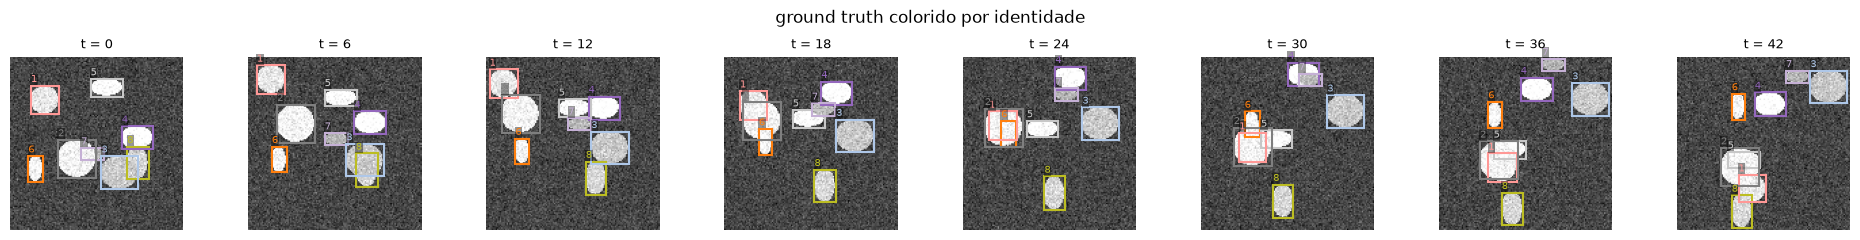

In [2]:
video = generate_video(
    n_objects=8,
    speed=2.0,
    occlusion_duration=12,
    n_frames=48,
    seed=SEED,
)

print("parâmetros :", json.dumps(video.params, indent=None))
print("frames     :", video.frames.shape, video.frames.dtype)
print("gt         :", video.gt.shape, "(frame, id, x1, y1, x2, y2, visibility)")
print("oclusões planejadas:", video.occlusions)

fig = show_frames(video, frames=range(0, 48, 6), gt=video.gt, title="ground truth colorido por identidade")
plt.show()

### Requisito verificável: a oclusão é de verdade

O ocultador está na frente, então enquanto ele cobre o ocultado o mapa de rótulos **não tem nenhum pixel** do ocultado — a visibilidade vai a zero. A figura abaixo é a exigida no enunciado: uma trajetória que some por $N$ quadros e volta. O intervalo vermelho é **medido** no mapa de rótulos (`video.occlusion_intervals`), não lido do parâmetro.

alvo: 12 quadros de oclusão total do objeto 1 pelo objeto 2
medido no mapa de rótulos: [(23, 34)]  ->  [12] quadros


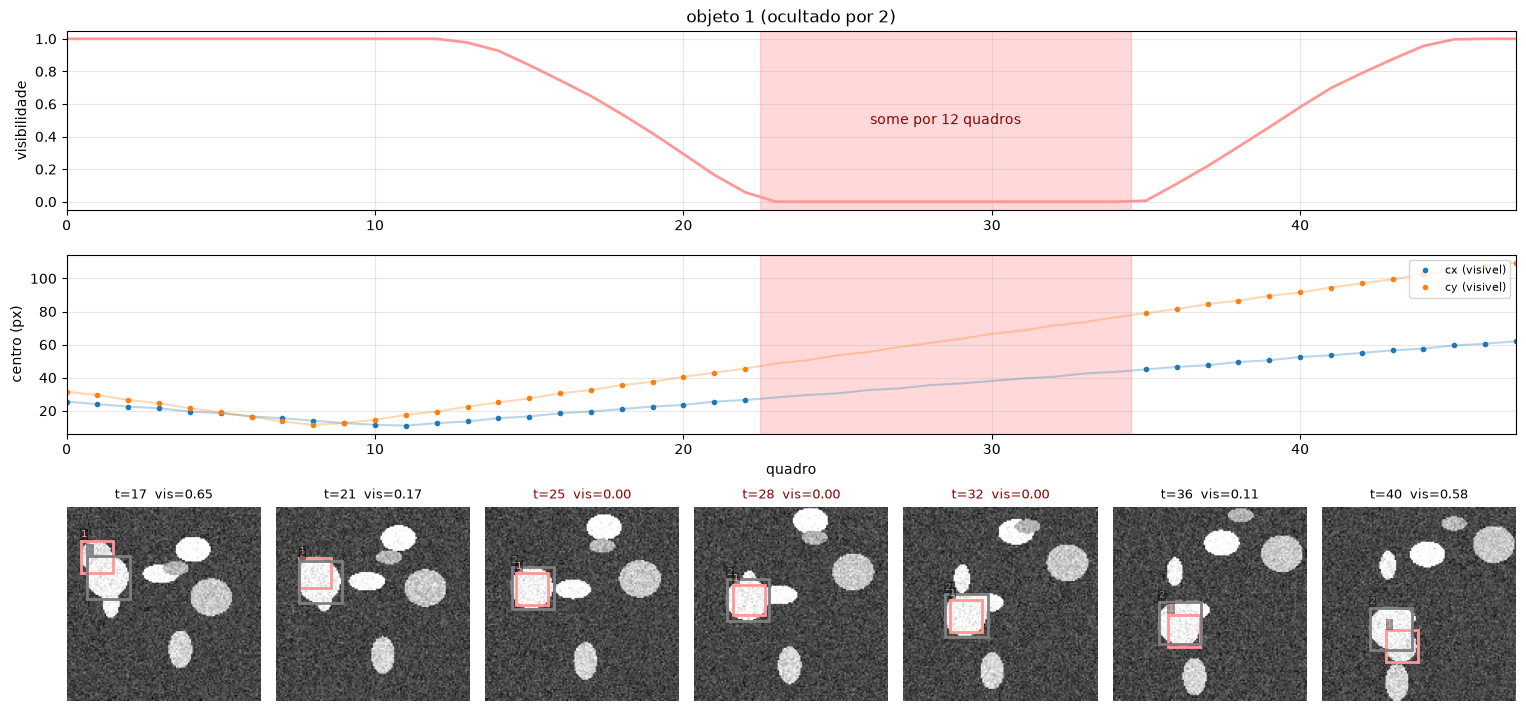

In [3]:
occ = video.occlusions[0]
a, b = occ["occludee"], occ["occluder"]

measured = video.occlusion_intervals(max_visibility=0.0)
print(f"alvo: {occ['target_duration']} quadros de oclusão total do objeto {a} pelo objeto {b}")
print(f"medido no mapa de rótulos: {measured.get(a)}  ->  "
      f"{[e - s + 1 for s, e in measured.get(a, [])]} quadros")

fig = plot_occlusion_trajectory(video, track_id=a, occluder_id=b, n_snapshots=7)
plt.show()

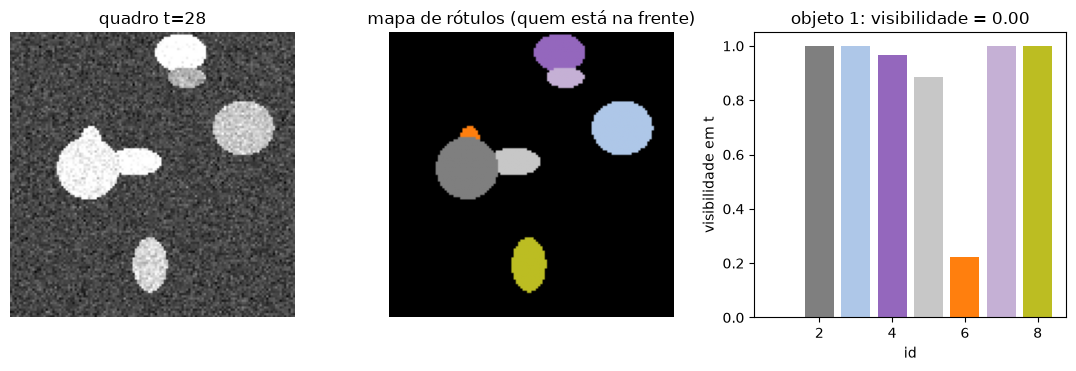

ids presentes no mapa de rótulos em t = 28 : [2, 3, 4, 5, 6, 7, 8]


In [4]:
# O mapa de rótulos no meio da oclusão: o id do ocultado não aparece.
s, e = measured[a][0]
t_mid = (s + e) // 2

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))

axes[0].imshow(video.frames[t_mid], cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"quadro t={t_mid}")

labels = video.label_maps[t_mid]
rgb = np.zeros((*labels.shape, 3))
for i in np.unique(labels):
    if i > 0:
        rgb[labels == i] = id_color(i)
axes[1].imshow(rgb)
axes[1].set_title("mapa de rótulos (quem está na frente)")

axes[2].bar(np.arange(1, video.params["n_objects"] + 1),
            [video.visibility_of(i)[t_mid] for i in range(1, video.params["n_objects"] + 1)],
            color=[id_color(i) for i in range(1, video.params["n_objects"] + 1)])
axes[2].set_ylim(0, 1.05)
axes[2].set_xlabel("id")
axes[2].set_ylabel("visibilidade em t")
axes[2].set_title(f"objeto {a}: visibilidade = {video.visibility_of(a)[t_mid]:.2f}")

for ax in axes[:2]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("ids presentes no mapa de rótulos em t =", t_mid, ":", sorted(np.unique(labels)[1:].tolist()))
assert a not in np.unique(labels), "o ocultado ainda aparece no mapa — não é oclusão"

### Os botões fazem o que dizem

O enunciado pede que número de objetos, velocidade típica e duração da oclusão sejam parâmetros. Abaixo, para cada valor do botão e várias seeds, o que o vídeo gerado **de fato** contém: número de identidades, deslocamento médio por quadro (px) e duração medida da oclusão total.

In [5]:
rows = []

for D in [0, 5, 10, 20, 30]:
    for speed in [0.5, 2.0, 6.0]:
        for seed in range(3):
            v = generate_video(n_objects=8, speed=speed, occlusion_duration=D, n_frames=60, seed=seed)

            # deslocamento médio por quadro dos centros (todos os objetos)
            disp = []
            for i in range(1, 9):
                traj = v.trajectory_of(i)
                c = (traj[:, :2] + traj[:, 2:]) / 2
                d = np.linalg.norm(np.diff(c, axis=0), axis=1)
                disp.append(np.nanmean(d))

            intervals = v.occlusion_intervals(0.0)
            if D > 0:
                occ_len = [e - s + 1 for s, e in intervals.get(v.occlusions[0]["occludee"], [])]
                occ_len = max(occ_len) if occ_len else 0
            else:
                occ_len = 0

            rows.append({
                "occlusion_duration": D, "speed": speed, "seed": seed,
                "n_ids": len(np.unique(v.gt[:, ID])),
                "px/quadro": float(np.mean(disp)),
                "oclusão medida": occ_len,
            })

knobs = pd.DataFrame(rows)
summary = knobs.groupby(["occlusion_duration", "speed"]).agg(
    n_ids=("n_ids", "mean"),
    px_por_quadro=("px/quadro", "mean"),
    oclusao_medida=("oclusão medida", "mean"),
    oclusao_std=("oclusão medida", "std"),
)
print(summary.to_string())

                          n_ids  px_por_quadro  oclusao_medida  oclusao_std
occlusion_duration speed                                                   
0                  0.5      8.0          0.598           0.000        0.000
                   2.0      8.0          2.130           0.000        0.000
                   6.0      8.0          6.233           0.000        0.000
5                  0.5      8.0          0.740           5.667        0.577
                   2.0      8.0          2.263           5.333        0.577
                   6.0      8.0          6.198           6.000        1.732
10                 0.5      8.0          0.720          10.000        0.000
                   2.0      8.0          2.172          10.000        0.000
                   6.0      8.0          6.174          10.000        0.000
20                 0.5      8.0          0.688          20.333        0.577
                   2.0      8.0          2.115          20.667        0.577
            

## 2. O simulador de detector

`simulate_detector(gt, drop_rate, noise_std, fp_rate, min_visibility)`:

- objetos com `visibility < min_visibility` **não são detectados** — é assim que a oclusão vira falta de detecção;
- dos restantes, uma fração `drop_rate` é descartada ao acaso;
- cada coordenada recebe ruído gaussiano de desvio `noise_std` × (largura ou altura da caixa);
- `fp_rate` falsos positivos por quadro (Poisson), com caixas de tamanho plausível e score baixo–médio.

O score de cada detecção cresce com a visibilidade, então o ranking por confiança do mAP tem algum sentido. Três intensidades, o mesmo vídeo:

          drop_rate  noise_std  fp_rate  n_det  n_gt  TP@0.5  FP@0.5  FN@0.5  AP@0.50  AP@0.75  mAP@[.50:.95]
detector                                                                                                     
perfeito       0.00       0.00      0.0    333   384     333       0      51    0.867    0.867          0.867
leve           0.05       0.03      0.2    325   384     319       6      65    0.831    0.831          0.691
médio          0.15       0.08      1.0    325   384     279      46     105    0.726    0.341          0.389
pesado         0.30       0.15      3.0    372   384     203     169     181    0.465    0.027          0.137


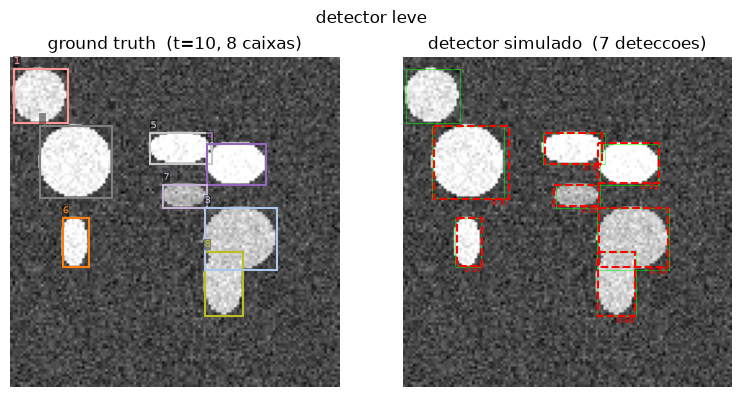

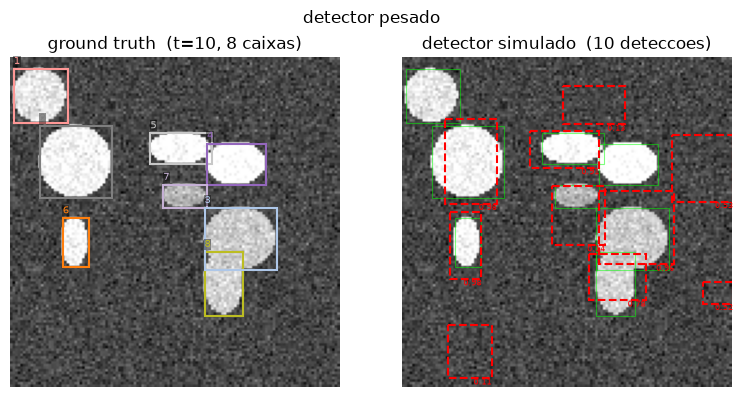

In [6]:
LEVELS = {
    "perfeito": dict(drop_rate=0.0, noise_std=0.00, fp_rate=0.0),
    "leve":     dict(drop_rate=0.05, noise_std=0.03, fp_rate=0.2),
    "médio":    dict(drop_rate=0.15, noise_std=0.08, fp_rate=1.0),
    "pesado":   dict(drop_rate=0.30, noise_std=0.15, fp_rate=3.0),
}

detections = {}
rows = []

for name, params in LEVELS.items():
    det = simulate_detector(video.gt, min_visibility=0.5, seed=SEED, **params)
    detections[name] = det

    map_value, aps = mean_average_precision(det, video.gt)
    tp, fp, fn = detection_counts(det, video.gt, iou_threshold=0.5)

    rows.append({"detector": name, **params, "n_det": len(det), "n_gt": len(video.gt),
                 "TP@0.5": tp, "FP@0.5": fp, "FN@0.5": fn,
                 "AP@0.50": aps[0.5], "AP@0.75": aps[0.75], "mAP@[.50:.95]": map_value})

detector_table = pd.DataFrame(rows).set_index("detector")
print(detector_table.to_string())

t_show = 10
for name in ["leve", "pesado"]:
    fig = plot_detector_simulation(video, t_show, video.gt, detections[name], title=f"detector {name}")
    plt.show()

Com o detector *perfeito* o mAP ainda não é 1: os objetos com visibilidade abaixo de 0,5 (o ocultado durante a oclusão, e cruzamentos ocasionais) ficam sem detecção — são FN legítimos, o detector não vê o que está atrás. O resto da degradação é monotônica nos três botões, que é o que a Parte 5 precisa.

## 3. A métrica e seus testes

Tudo em `src/nn/metrics.py` (o entregável `metrics.py` na raiz re-exporta e dá uma linha de comando para arquivos do MOTChallenge). Definições:

- **IDF1** (Ristani et al., 2016): atribuição **global** um-para-um entre identidades previstas e verdadeiras, ao longo da sequência inteira, que maximiza o número de quadros casados (par casado num quadro = as duas caixas existem e IoU ≥ 0,5). $\text{IDTP}$ = quadros casados pela atribuição; $\text{IDFP}$ = detecções previstas − IDTP; $\text{IDFN}$ = detecções verdadeiras − IDTP;
  $$\text{IDF1} = \frac{2\,\text{IDTP}}{2\,\text{IDTP} + \text{IDFP} + \text{IDFN}}.$$
  A atribuição é resolvida com o Hungarian (`scipy.optimize.linear_sum_assignment`, permitido) sobre a matriz de contagens.
- **ID switch** (CLEAR MOT): casamos previsões e GT **quadro a quadro** (mantendo o par do quadro anterior quando ele ainda vale, Hungarian no resto). A identidade verdadeira $g$ sofre um switch no quadro $t$ se está casada com $p$ e a **última** vez que foi casada (em qualquer quadro anterior) foi com $p' \neq p$.
- **Fragmentação**: $g$ estava casada, ficou ≥ 1 quadro presente no GT sem par, e voltou a ser casada.
- **Erro de contagem de identidades**: $|\#\text{ids previstos} - \#\text{ids verdadeiros}|$ e a razão entre eles.

Os três casos construídos à mão: dois objetos andando em linhas paralelas por $T = 40$ quadros, $k = 20$.

                        IDF1   IDP   IDR  IDSW  FRAG  n_gt_ids  n_pred_ids  count_error   MOTA  switches (frame, gt, de->para)
caso                                                                                                                          
(a) pred = gt           1.00  1.00  1.00     0     0         2           2            0  1.000                              []
(b) ids trocadas em k   0.50  0.50  0.50     2     0         2           2            0  0.975  [(20, 1, 1, 2), (20, 2, 2, 1)]
(c) track partida em k  0.75  0.75  0.75     1     0         2           3            1  0.988                 [(20, 1, 1, 3)]

os três casos passam.


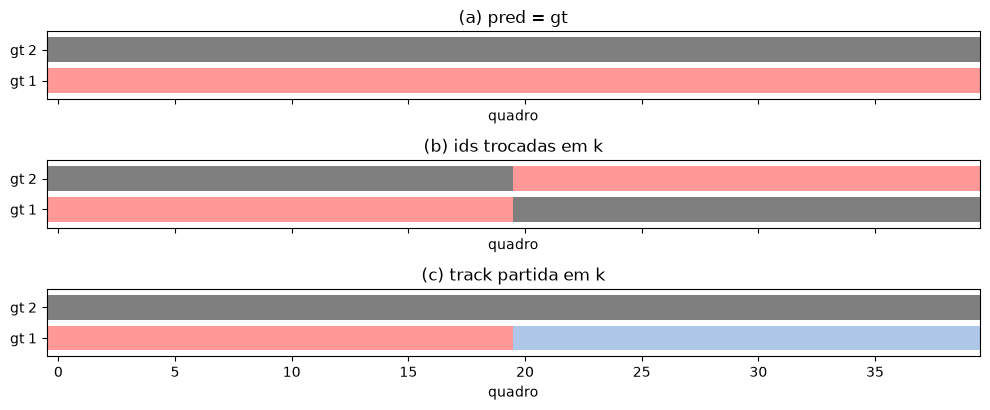

In [7]:
def straight_tracks(n_ids=2, n_frames=40, spacing=30.0, size=10.0):
    rows = []
    for i in range(n_ids):
        for t in range(n_frames):
            x, y = 5.0 + t, 5.0 + i * spacing
            rows.append((t, i + 1, x, y, x + size, y + size, 1.0))
    return np.asarray(rows, dtype=np.float64)

T, k = 40, 20
gt_toy = straight_tracks(n_ids=2, n_frames=T)

# (a) predição = ground truth
pred_a = gt_toy.copy()

# (b) duas identidades trocadas a partir do quadro k
pred_b = gt_toy.copy()
late = pred_b[:, FRAME] >= k
pred_b[late & (gt_toy[:, ID] == 1), ID] = 2
pred_b[late & (gt_toy[:, ID] == 2), ID] = 1

# (c) uma track partida em duas no meio (id 1 vira id 3 a partir de k)
pred_c = gt_toy.copy()
pred_c[(pred_c[:, FRAME] >= k) & (gt_toy[:, ID] == 1), ID] = 3

cases = {"(a) pred = gt": pred_a, "(b) ids trocadas em k": pred_b, "(c) track partida em k": pred_c}

rows = []
for name, pred in cases.items():
    stats = evaluate_tracking(pred, gt_toy, iou_threshold=0.5)
    sw = id_switches(pred, gt_toy)
    rows.append({"caso": name, **{m: stats[m] for m in ["IDF1", "IDP", "IDR", "IDSW", "FRAG", "n_gt_ids", "n_pred_ids", "count_error", "MOTA"]},
                 "switches (frame, gt, de->para)": sw["switch_events"]})

metric_table = pd.DataFrame(rows).set_index("caso")
print(metric_table.to_string())

# os valores esperados, calculados à mão
assert np.isclose(metric_table.loc["(a) pred = gt", "IDF1"], 1.0) and metric_table.loc["(a) pred = gt", "IDSW"] == 0
assert np.isclose(metric_table.loc["(b) ids trocadas em k", "IDF1"], 0.5) and metric_table.loc["(b) ids trocadas em k", "IDSW"] == 2
assert np.isclose(metric_table.loc["(c) track partida em k", "IDF1"], 0.75) and metric_table.loc["(c) track partida em k", "IDSW"] == 1
print("\nos três casos passam.")

fig, axes = plt.subplots(3, 1, figsize=(10, 4.2), sharex=True)
for ax, (name, pred) in zip(axes, cases.items()):
    plot_tracks_timeline(pred, gt_toy, ax=ax, title=name)
plt.tight_layout()
plt.show()

**Por que (b) e (c) não dão o mesmo número.**

- Em **(b)** as duas identidades trocam de lugar no quadro $k$: cada GT muda de parceiro uma vez → **2 switches**. No IDF1, a atribuição global só pode dar a cada GT *um* id previsto; qualquer escolha cobre metade dos quadros de cada um → IDTP $= 40$ de $80$ → **IDF1 = 0,5**.
- Em **(c)** só a track 1 é partida (id 1 → id 3): **1 switch**. O GT 2 é coberto por inteiro (40 quadros) e o GT 1 por metade (20) → IDTP $= 60$ → **IDF1 = 0,75**.

Ou seja: o IDF1 penaliza (b) mais que (c) porque uma troca destrói a identidade de *dois* objetos ao mesmo tempo, enquanto uma fragmentação de id destrói a de um. E a contagem de identidades únicas separa os dois de outro jeito — (b) tem o número certo de ids (2), (c) tem um a mais. Na linha do tempo acima, cada faixa é um GT e a cor é o id previsto casado naquele quadro.

## 4. O baseline no piso fácil

A **regra de associação** da Parte 1 (`Tracker` com `StaticMotion`, documentada no cabeçalho de `src/nn/tracking.py`):

1. a cada quadro, IoU entre a **última caixa observada** de cada track viva e cada detecção do quadro;
2. matching **guloso por IoU decrescente**, limiar fixo `iou_threshold = 0.3`;
3. detecção sem par → **track nova** (id novo, nunca reutilizado);
4. track sem par → envelhece; com mais de `max_age = 5` quadros sem observação, **morre**;
5. só tracks observadas no quadro entram na saída (uma track em *coasting* não emite caixa).

Piso fácil: 5 elipses, `speed = 0.5` px/quadro, sem oclusão planejada, detector perfeito (só o portão de visibilidade). O IDF1 tem que ficar muito perto de 1.

       IDF1  IDSW  FRAG  n_gt_ids  n_pred_ids  id_ratio    mAP
seed                                                          
100   1.000     0     0         5           5       1.0  1.000
101   1.000     0     0         5           5       1.0  1.000
102   1.000     0     0         5           5       1.0  1.000
103   1.000     0     0         5           5       1.0  1.000
104   1.000     0     0         5           5       1.0  1.000
105   1.000     0     0         5           5       1.0  1.000
106   0.977     0     0         5           5       1.0  0.955
107   0.961     0     0         5           5       1.0  0.925
108   0.947     0     0         5           5       1.0  0.900
109   1.000     0     0         5           5       1.0  1.000

IDF1 médio no piso fácil: 0.9885 ± 0.0197


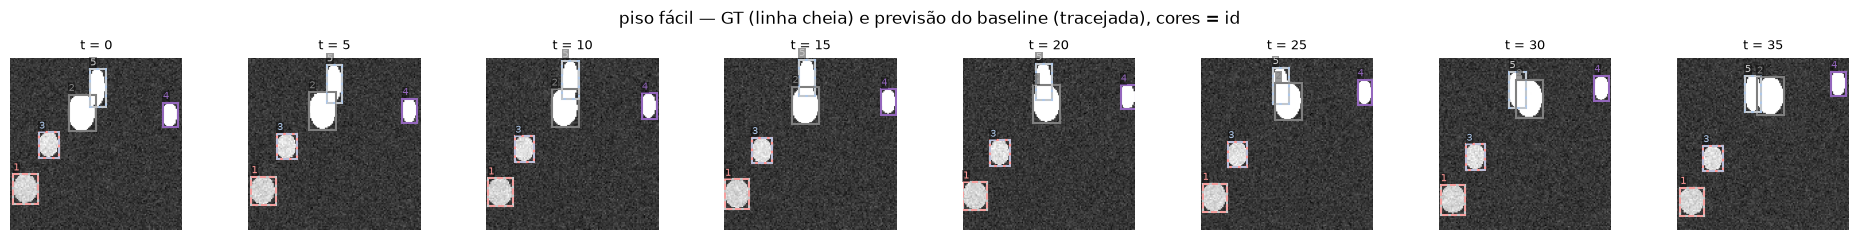

In [8]:
TRACKER_PARAMS = dict(iou_threshold=0.3, max_age=5, matching="greedy")

rows = []
for seed in range(10):
    v = generate_video(n_objects=5, speed=0.5, occlusion_duration=0, n_frames=40, seed=100 + seed)
    det = simulate_detector(v.gt, min_visibility=0.5, seed=seed)
    pred = Tracker(StaticMotion(), **TRACKER_PARAMS).run(det)
    stats = evaluate_tracking(pred, v.gt)
    rows.append({"seed": 100 + seed, **{m: stats[m] for m in ["IDF1", "IDSW", "FRAG", "n_gt_ids", "n_pred_ids", "id_ratio", "mAP"]}})

easy = pd.DataFrame(rows).set_index("seed")
print(easy.to_string())
print(f"\nIDF1 médio no piso fácil: {easy['IDF1'].mean():.4f} ± {easy['IDF1'].std():.4f}")

fig = show_frames(v, frames=range(0, 40, 5), gt=v.gt, pred=pred,
                  title="piso fácil — GT (linha cheia) e previsão do baseline (tracejada), cores = id")
plt.show()

Com um detector *imperfeito* mas leve (5 % de descarte, 3 % de ruído, 0,2 FP/quadro) o piso ainda segura? Cada falso positivo vira uma track nova de um quadro — isso não muda o IDF1 muito, mas explode a contagem de identidades.

In [9]:
rows = []
for seed in range(10):
    v = generate_video(n_objects=5, speed=0.5, occlusion_duration=0, n_frames=40, seed=100 + seed)
    det = simulate_detector(v.gt, min_visibility=0.5, seed=seed, **LEVELS["leve"])
    pred = Tracker(StaticMotion(), **TRACKER_PARAMS).run(det)
    stats = evaluate_tracking(pred, v.gt)
    rows.append({"seed": 100 + seed, **{m: stats[m] for m in ["IDF1", "IDSW", "FRAG", "n_gt_ids", "n_pred_ids", "id_ratio", "mAP"]}})

easy_noisy = pd.DataFrame(rows).set_index("seed")
print(easy_noisy.mean().to_frame("média").T.to_string())

        IDF1  IDSW  FRAG  n_gt_ids  n_pred_ids  id_ratio    mAP
média  0.944   0.0   7.7       5.0        13.7      2.74  0.785


## 5. Girando os botões — onde o baseline começa a quebrar

Um botão por vez, com os outros fixos no piso fácil, 8 seeds por ponto. O detector é o "perfeito" com portão de visibilidade 0,5 — assim a única coisa que muda entre pontos é o vídeo. Na varredura de oclusão a velocidade base sobe para 2 px/quadro: com objetos quase parados a oclusão não custa nada a quem guarda a última caixa, e o que queremos ver é a interação **oclusão × movimento**.

Quatro configurações em cada curva: a associação ingênua e o **filtro de Kalman de velocidade constante** (`KalmanMotion`, permitido só como baseline de comparação), cada uma com `max_age` = 5 e 30. O Kalman diz quanto do fracasso é *não ter modelo de movimento nenhum*; o `max_age` diz quanto é *desistir cedo demais* — e mostra o preço de desistir tarde.

Este é o ensaio do gráfico de dois painéis da Parte 1: em cima mAP por quadro e IDF1, embaixo a razão #ids previstos / #ids verdadeiros e os ID switches por identidade verdadeira.

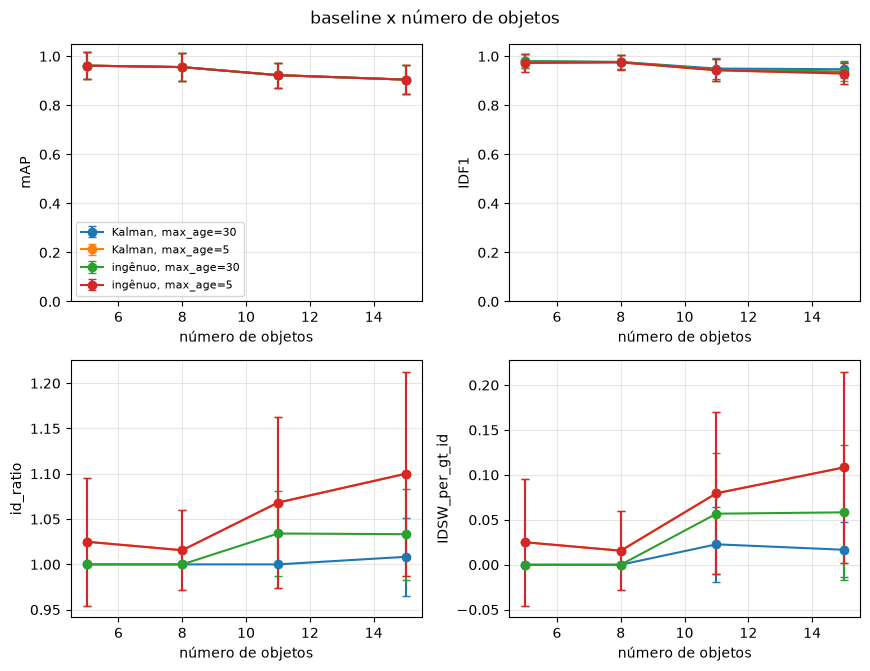

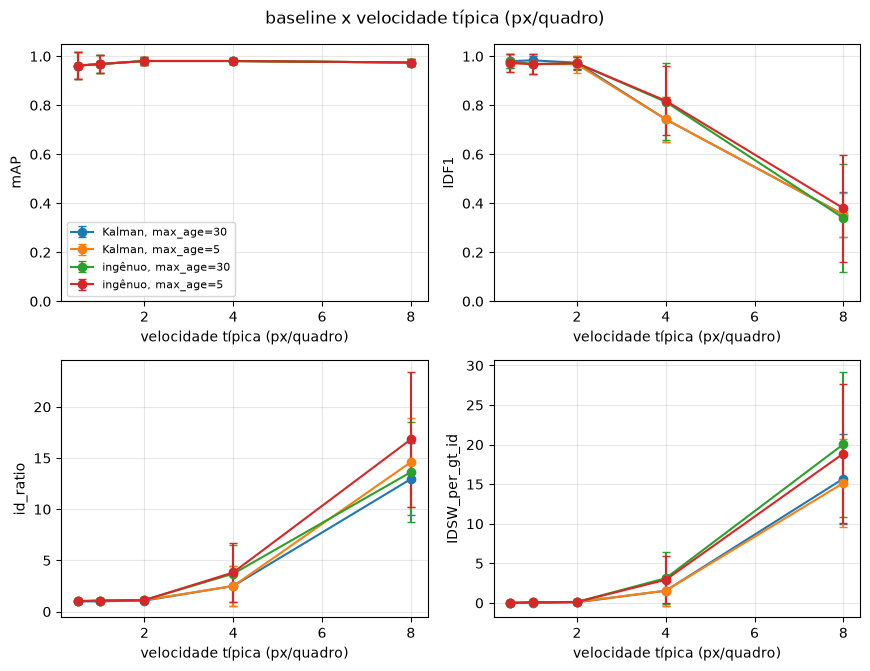

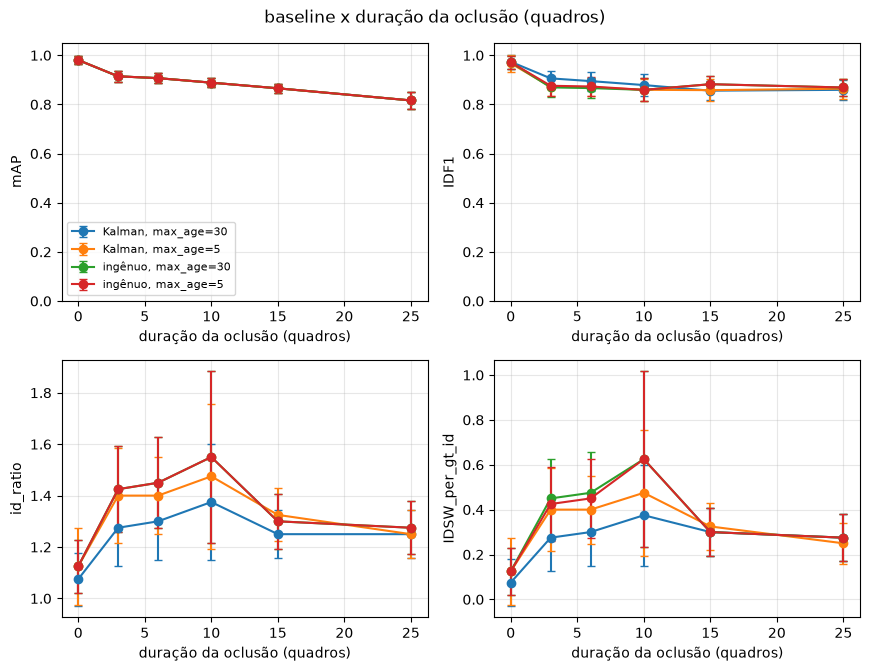

In [10]:
N_SEEDS = 8
BASE = dict(n_objects=5, speed=0.5, occlusion_duration=0, n_frames=40)

SWEEPS = {
    "n_objects":          {"values": [5, 8, 11, 15],            "base": BASE},
    "speed":              {"values": [0.5, 1.0, 2.0, 4.0, 8.0], "base": BASE},
    "occlusion_duration": {"values": [0, 3, 6, 10, 15, 25],     "base": {**BASE, "speed": 2.0}},
}

TRACKERS = {
    "ingênuo, max_age=5":  lambda: Tracker(StaticMotion(), iou_threshold=0.3, max_age=5,  matching="greedy"),
    "ingênuo, max_age=30": lambda: Tracker(StaticMotion(), iou_threshold=0.3, max_age=30, matching="greedy"),
    "Kalman, max_age=5":   lambda: Tracker(KalmanMotion(), iou_threshold=0.3, max_age=5,  matching="greedy"),
    "Kalman, max_age=30":  lambda: Tracker(KalmanMotion(), iou_threshold=0.3, max_age=30, matching="greedy"),
}

rows = []

for knob, sweep_spec in SWEEPS.items():
    for value in sweep_spec["values"]:
        for seed in range(N_SEEDS):

            params = {**sweep_spec["base"], knob: value}
            v = generate_video(seed=1000 + seed, **params)
            det = simulate_detector(v.gt, min_visibility=0.5, seed=seed)

            for tracker_name, make_tracker in TRACKERS.items():
                pred = make_tracker().run(det)
                stats = evaluate_tracking(pred, v.gt)
                rows.append({"knob": knob, "value": value, "seed": seed, "tracker": tracker_name, **stats})

sweep = pd.DataFrame(rows)
sweep.to_csv(os.path.join(RESULTS_DIR, "0_sintetic_sweep.csv"), index=False)

AX_LABELS = {"n_objects": "número de objetos", "speed": "velocidade típica (px/quadro)",
             "occlusion_duration": "duração da oclusão (quadros)"}

for knob in SWEEPS:
    part = sweep[sweep["knob"] == knob].rename(columns={"value": knob})
    fig = plot_breakdown(part, knob, metrics=("mAP", "IDF1", "id_ratio", "IDSW_per_gt_id"), ncols=2,
                         hue="tracker", title=f"baseline x {AX_LABELS[knob]}", ax_labels=AX_LABELS)
    plt.show()

In [11]:
table = (sweep.groupby(["knob", "value", "tracker"])[["IDF1", "IDSW_per_gt_id", "id_ratio", "FRAG"]]
         .mean().round(3)
         .unstack("tracker"))
print(table.to_string())

                                       IDF1                                                              IDSW_per_gt_id                                                                    id_ratio                                                                        FRAG                                                         
tracker                  Kalman, max_age=30 Kalman, max_age=5 ingênuo, max_age=30 ingênuo, max_age=5 Kalman, max_age=30 Kalman, max_age=5 ingênuo, max_age=30 ingênuo, max_age=5 Kalman, max_age=30 Kalman, max_age=5 ingênuo, max_age=30 ingênuo, max_age=5 Kalman, max_age=30 Kalman, max_age=5 ingênuo, max_age=30 ingênuo, max_age=5
knob               value                                                                                                                                                                                                                                                                                                                
n_objects    

### Onde quebra, e por quê

Lendo as curvas (números na tabela acima; baseline = "ingênuo, max_age=5"):

- **Número de objetos** (a 0,5 px/quadro): de 5 para 15 elipses o IDF1 cai pouco (0,973 → 0,930), mas as fragmentações por vídeo sobem de 0,1 para 1,75 e os switches por identidade de 0,025 para 0,108. A causa são os **cruzamentos incidentais**: uma elipse menor passa atrás de uma maior, a visibilidade cai abaixo de 0,5, o detector a perde por alguns quadros e, com `max_age = 5`, a track morre e renasce com id novo. Com `max_age = 30` o mesmo rastreador ingênuo quase não sofre (0,938–0,980) — a 0,5 px/quadro o objeto mal sai de onde estava.
- **Velocidade** (5 objetos, sem oclusão): até 2 px/quadro nada acontece (0,972). Em 4 px/quadro o baseline quebra (IDF1 0,818, quase 3 switches por identidade, 3,8× mais ids que o verdadeiro) e em 8 px/quadro ele colapsa (0,38, ~19 switches por identidade): as velocidades individuais vão de 4 a 12 px/quadro e o IoU entre a última caixa e a caixa seguinte de uma elipse de 10–28 px cai abaixo do limiar de 0,3 — cada quadro vira um nascimento. É a falha mais elementar: **"última caixa" não é modelo de movimento**.
- **Oclusão** (a 2 px/quadro): qualquer oclusão total de 3 quadros ou mais já derruba o baseline — os switches por identidade saltam de 0,125 para 0,4–0,6 e ficam lá, **independentemente de $D$**: com as fases de oclusão parcial (visibilidade < 0,5), o objeto some do detector por mais de `max_age = 5` quadros em todos os casos, a track morre e o objeto renasce com outro id. Subir `max_age` para 30 não resolve para o rastreador ingênuo: durante a oclusão o objeto anda $2 \times (D + \text{fases parciais})$ px e a última caixa fica para trás. O IDF1 muda pouco (0,97 → 0,86–0,88) porque só um dos cinco objetos é ocluído; é o **switch por identidade** que denuncia.

**E o Kalman de velocidade constante?** Numa linha reta ele funciona (a caixa prevista após 20 quadros sem observação ainda tem IoU 0,6 com a verdadeira — `tests/tests.py`), e por isso ganha do ingênuo nas oclusões curtas (0,906 / 0,895 / 0,879 contra 0,869 / 0,867 / 0,859 em $D$ = 3 / 6 / 10, com `max_age = 30`). Mas perde a vantagem em $D \geq 15$ e é **pior** que o ingênuo em 4 px/quadro (0,743 contra 0,818): as elipses **ricocheteiam nas bordas**, e velocidade constante prevê através da parede. Quanto mais rápido o objeto ou mais longa a oclusão, maior a chance de haver um ricochete no meio — e o filtro, que não sabe que existe parede, coasta para o lugar errado enquanto a detecção reaparece em outro. O ingênuo, que não extrapola, erra menos nesses casos. É um artefato do mundo sintético, mas tem análogo real (pedestres mudam de direção), e é exatamente o tipo de regularidade que um modelo de movimento **aprendido** nessas trajetórias (Parte 2, Trilha A) pode capturar e o filtro de velocidade constante não.

### Dois vídeos difíceis vistos de perto

A linha do tempo abaixo é a mesma da seção 3: uma faixa por identidade verdadeira, cor = id previsto casado naquele quadro, cinza = sem par. Trocas de cor dentro de uma faixa são ID switches.

velocidade 8 px/quadro | ingênuo, max_age=30: IDF1=0.542  IDSW=52  ids previstos=44 / 5


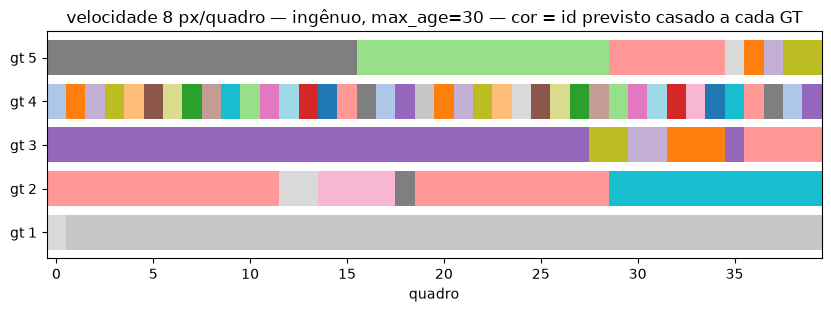

velocidade 8 px/quadro | Kalman, max_age=30: IDF1=0.339  IDSW=53  ids previstos=52 / 5


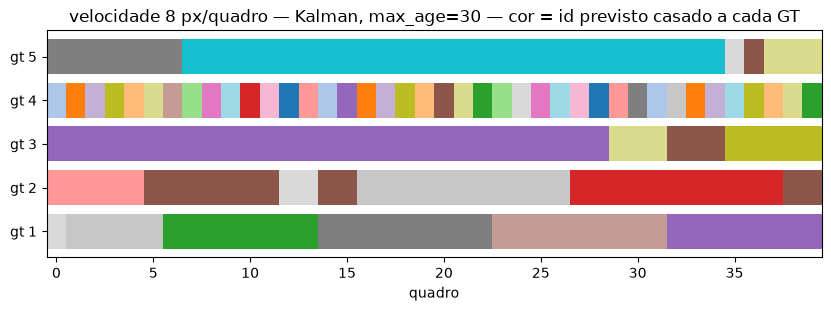

oclusão de 15 quadros a 2 px/quadro | ingênuo, max_age=30: IDF1=0.900  IDSW=1  ids previstos=6 / 5


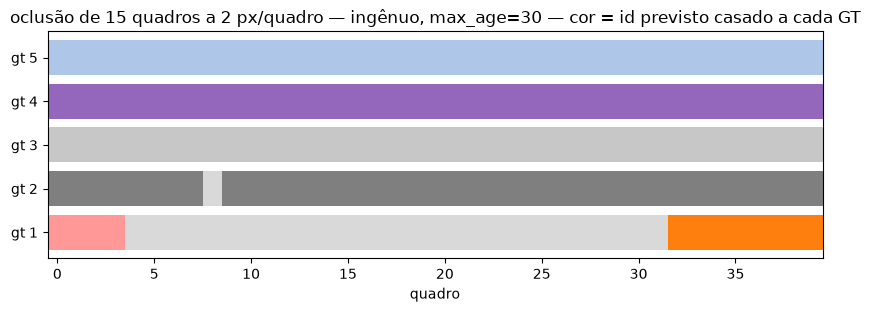

oclusão de 15 quadros a 2 px/quadro | Kalman, max_age=30: IDF1=0.814  IDSW=2  ids previstos=6 / 5


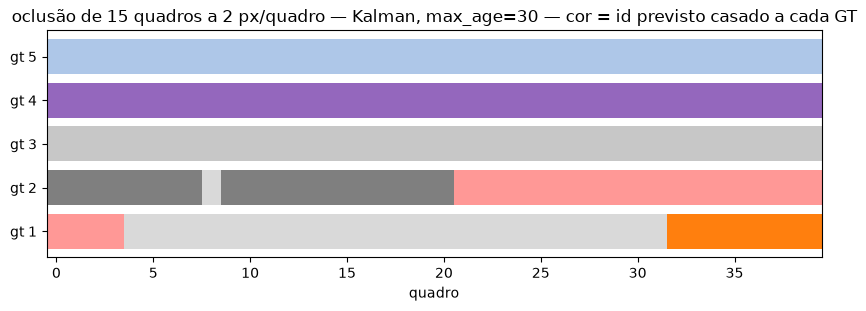

In [12]:
# Um exemplo de cada tipo de quebra, lado a lado: o mesmo vídeo difícil visto pelo GT e pelo baseline.
v_fast = generate_video(seed=1003, **{**BASE, "speed": 8.0})
v_occl = generate_video(seed=1003, **{**BASE, "speed": 2.0, "occlusion_duration": 15})

for name, v in [("velocidade 8 px/quadro", v_fast), ("oclusão de 15 quadros a 2 px/quadro", v_occl)]:
    det = simulate_detector(v.gt, min_visibility=0.5, seed=3)
    for tracker_name in ["ingênuo, max_age=30", "Kalman, max_age=30"]:
        pred = TRACKERS[tracker_name]().run(det)
        stats = evaluate_tracking(pred, v.gt)
        print(f"{name} | {tracker_name}: IDF1={stats['IDF1']:.3f}  IDSW={stats['IDSW']}  "
              f"ids previstos={stats['n_pred_ids']} / {stats['n_gt_ids']}")
        fig = plot_tracks_timeline(pred, v.gt, title=f"{name} — {tracker_name} — cor = id previsto casado a cada GT")
        plt.show()

In [13]:
# ============================================================
# SALVA OS NÚMEROS DA PARTE 0
# ============================================================

summary = {
    "gerador": {
        "oclusao_alvo_vs_medida": knobs.groupby("occlusion_duration")["oclusão medida"].mean().round(2).to_dict(),
        "px_por_quadro_vs_speed": knobs.groupby("speed")["px/quadro"].mean().round(2).to_dict(),
    },
    "detector": detector_table[["mAP@[.50:.95]", "AP@0.50", "TP@0.5", "FP@0.5", "FN@0.5"]].to_dict(orient="index"),
    "metrica_casos": metric_table[["IDF1", "IDSW", "FRAG", "n_pred_ids"]].to_dict(orient="index"),
    "piso_facil": {
        "IDF1_medio": float(easy["IDF1"].mean()),
        "IDF1_std": float(easy["IDF1"].std()),
        "IDSW_total": int(easy["IDSW"].sum()),
        "IDF1_medio_detector_leve": float(easy_noisy["IDF1"].mean()),
    },
    "tracker_piso_facil": TRACKER_PARAMS,
    "sweep_IDF1": {
        knob: {
            tracker: sweep[(sweep.knob == knob) & (sweep.tracker == tracker)]
                     .groupby("value")["IDF1"].mean().round(3).to_dict()
            for tracker in TRACKERS
        }
        for knob in SWEEPS
    },
    "sweep_IDSW_per_gt_id": {
        knob: {
            tracker: sweep[(sweep.knob == knob) & (sweep.tracker == tracker)]
                     .groupby("value")["IDSW_per_gt_id"].mean().round(3).to_dict()
            for tracker in TRACKERS
        }
        for knob in SWEEPS
    },
}

with open(os.path.join(RESULTS_DIR, "0_sintetic_tests.json"), "w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2, ensure_ascii=False, default=float)

print(json.dumps(summary, indent=2, ensure_ascii=False, default=float))

{
  "gerador": {
    "oclusao_alvo_vs_medida": {
      "0": 0.0,
      "5": 5.67,
      "10": 10.0,
      "20": 20.33,
      "30": 30.67
    },
    "px_por_quadro_vs_speed": {
      "0.5": 0.68,
      "2.0": 2.16,
      "6.0": 6.24
    }
  },
  "detector": {
    "perfeito": {
      "mAP@[.50:.95]": 0.8671875,
      "AP@0.50": 0.8671875,
      "TP@0.5": 333,
      "FP@0.5": 0,
      "FN@0.5": 51
    },
    "leve": {
      "mAP@[.50:.95]": 0.6907444379437703,
      "AP@0.50": 0.830712890625,
      "TP@0.5": 319,
      "FP@0.5": 6,
      "FN@0.5": 65
    },
    "médio": {
      "mAP@[.50:.95]": 0.38882355372093685,
      "AP@0.50": 0.726247724621748,
      "TP@0.5": 279,
      "FP@0.5": 46,
      "FN@0.5": 105
    },
    "pesado": {
      "mAP@[.50:.95]": 0.13704426007598364,
      "AP@0.50": 0.4647356400185307,
      "TP@0.5": 203,
      "FP@0.5": 169,
      "FN@0.5": 181
    }
  },
  "metrica_casos": {
    "(a) pred = gt": {
      "IDF1": 1.0,
      "IDSW": 0,
      "FRAG": 0,
      "n_

## Conclusões da Parte 0

1. **Gerador**: os três botões controlam o que dizem controlar — a oclusão total medida no mapa de rótulos bate com `occlusion_duration` (5,7 / 10,0 / 20,3 / 30,7 quadros para alvos de 5 / 10 / 20 / 30) e o deslocamento por quadro segue `speed`. A oclusão é real: o ocultado some do mapa de rótulos (visibilidade 0) e volta; a figura da seção 1 é a exigida no enunciado.
2. **Detector simulado**: mAP@[.50:.95] de 0,87 (só o portão de visibilidade) → 0,69 → 0,39 → 0,14 nas intensidades leve / média / pesada, monotônico nos três botões. Pronto para a Parte 5.
3. **Métrica**: os três casos à mão passam com os valores calculados analiticamente — (a) IDF1 = 1, 0 switches; (b) 2 switches e IDF1 = 0,5; (c) 1 switch e IDF1 = 0,75. (b) e (c) diferem porque uma troca destrói duas identidades, uma partição destrói uma; a contagem de identidades únicas separa os dois na outra direção (2 vs 3 ids).
4. **Baseline no piso fácil**: IDF1 = 0,989 ± 0,020 em 10 seeds, zero switches. Com o detector "leve" ainda 0,944, mas 2,7× mais identidades que o verdadeiro — cada falso positivo é uma track nova de um quadro. Onde quebra: velocidade ≥ 4 px/quadro (IoU entre quadros consecutivos abaixo do limiar) e **qualquer** oclusão mais longa que `max_age`. Aumentar `max_age` só ajuda se o objeto não se mover; um modelo de movimento ajuda enquanto o movimento for previsível.

O que a Parte 1 herda: o `Tracker` com a regra documentada, `simulate_detector` para o teste de estresse, `metrics.py`, e a expectativa de que as sequências do MOT17 com câmera em movimento e oclusões longas sejam o análogo real dos dois botões que quebram o baseline.